In [4]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers


In [5]:
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input

In [6]:
# 1. Load Data

In [7]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42
DATA_DIR = '../data/train'
TEST_DIR = '../data/test'
train_ds = keras.utils.image_dataset_from_directory(
  DATA_DIR,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
  subset="training",
  validation_split=0.2,
  seed=SEED
)
keras.utils.set_random_seed(SEED)

Found 3654 files belonging to 3 classes.
Using 2924 files for training.


In [8]:
train_ds = keras.utils.image_dataset_from_directory(
  DATA_DIR,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
  subset="training",
  validation_split=0.2,
  seed=SEED
)

Found 3654 files belonging to 3 classes.
Using 2924 files for training.


In [9]:
val_ds = keras.utils.image_dataset_from_directory(
  DATA_DIR,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
  subset="validation",
  validation_split=0.2,
  seed=SEED
)

Found 3654 files belonging to 3 classes.
Using 730 files for validation.


In [10]:
test_ds = keras.utils.image_dataset_from_directory(
  TEST_DIR,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
)

Found 577 files belonging to 3 classes.


In [11]:
class_names = train_ds.class_names
print(class_names)

['paper', 'rock', 'scissors']


In [12]:
num_classes = len(class_names)
print(num_classes)

3


In [13]:
#  2. optimze input pipeline

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [15]:
# 3. Data Augmentation

In [16]:
data_aug = keras.Sequential([
    # ── Spatial ──────────────────────────────────────────────
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomShear(0.1),

    # ── Color / Appearance ───────────────────────────────────
    keras.layers.RandomContrast(0.2),
    keras.layers.RandomBrightness(0.2),

    # NEW: random hue/saturation shifts (great for real-world color variance)
    keras.layers.RandomHue(0.1),             # Keras 3 / tf.keras ≥ 2.13
    keras.layers.RandomSaturation(0.1),

    # ── Noise / Regularization ───────────────────────────────
    keras.layers.GaussianNoise(0.05),
], name="data_augmentation"
)

In [17]:
# 4. Build CNN From Scratch

In [18]:
base_model = MobileNetV2(
  weights="imagenet",
  include_top=False,
  input_shape=IMAGE_SIZE + (3,)
)
base_model.trainable = False

/var/folders/7n/jg0ph_ss3k37fgly50_n6kqw0000gn/T/ipykernel_23781/1270931171.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [19]:
inputs = keras.Input(shape=IMAGE_SIZE + (3,))
x = data_aug(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(num_classes, activation="softmax")(x),


In [20]:
model = keras.Model(inputs, output)

In [21]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [44]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10,
  callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
  )

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 0.9754 - loss: 0.0686 - val_accuracy: 0.9178 - val_loss: 0.2172
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.9815 - loss: 0.0533 - val_accuracy: 0.9082 - val_loss: 0.2524
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.9819 - loss: 0.0484 - val_accuracy: 0.9055 - val_loss: 0.2452
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.9815 - loss: 0.0485 - val_accuracy: 0.9192 - val_loss: 0.2090
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - accuracy: 0.9846 - loss: 0.0442 - val_accuracy: 0.9397 - val_loss: 0.1489
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.9860 - loss: 0.0435 - val_accuracy: 0.9397 - val_loss: 0.1473
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.9894 - loss: 0.0316 - val_accuracy: 0.9479 - val_loss: 0.1235
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.9891 - loss: 0.0343 - val_accu

In [23]:
test_loss, test_acc = model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8458 - loss: 0.3656


In [24]:
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss: {test_loss:.3f}")

Test accuracy: 0.846
Test loss: 0.366


In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [43]:
print(f"End training accuracy: {acc[-1]:.3f}")
print(f"End validation accuracy: {val_acc[-1]:.3f}")
print(f"End training loss: {loss[-1]:.3f}")
print(f"End validation loss: {val_loss[-1]:.3f}")

End training accuracy: 0.981
End validation accuracy: 0.911
End training loss: 0.059
End validation loss: 0.228


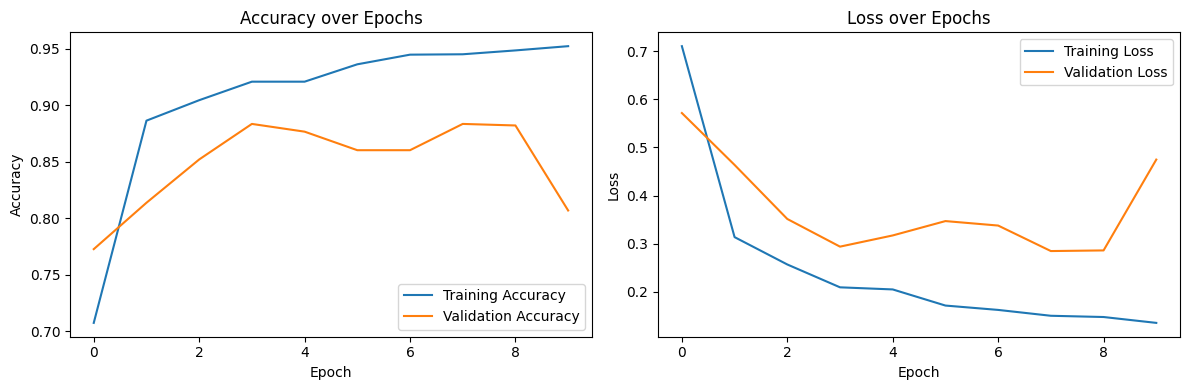

In [33]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(acc, label='Training Accuracy')
axes[0].plot(val_acc, label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

In [34]:
base_model.trainable = True
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [35]:
model.compile(
  optimizer= keras.optimizers.Adam(learning_rate=1e-5), 
  loss='sparse_categorical_crossentropy', 
  metrics=['accuracy'])

In [36]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs= history.epoch[-1] + 10,
  initial_epoch=history.epoch[-1] + 1,
  callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
  )

Epoch 17/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - accuracy: 0.9203 - loss: 0.2193 - val_accuracy: 0.8288 - val_loss: 0.4053
Epoch 18/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.9367 - loss: 0.1677 - val_accuracy: 0.8384 - val_loss: 0.4100
Epoch 19/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - accuracy: 0.9490 - loss: 0.1298 - val_accuracy: 0.8726 - val_loss: 0.3389
Epoch 20/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - accuracy: 0.9627 - loss: 0.1043 - val_accuracy: 0.8795 - val_loss: 0.3493
Epoch 21/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 0.9641 - loss: 0.0951 - val_accuracy: 0.8863 - val_loss: 0.3227
Epoch 22/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.9685 - loss: 0.0814 - val_accuracy: 0.8836 - val_loss: 0.3205
Epoch 23/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 0.9761 - loss: 0.0719 - val_accuracy: 0.8863 - val_loss: 0.3025
Epoch 24/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 0.9808 - loss: 0.0585 - 

In [37]:
test_loss, test_acc = model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8250 - loss: 0.5163


In [38]:
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss: {test_loss:.3f}")

Test accuracy: 0.825
Test loss: 0.516


In [39]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [42]:
print(f"End training accuracy: {acc[-1]:.3f}")
print(f"End validation accuracy: {val_acc[-1]:.3f}")
print(f"End training loss: {loss[-1]:.3f}")
print(f"End validation loss: {val_loss[-1]:.3f}")

End training accuracy: 0.981
End validation accuracy: 0.911
End training loss: 0.059
End validation loss: 0.228


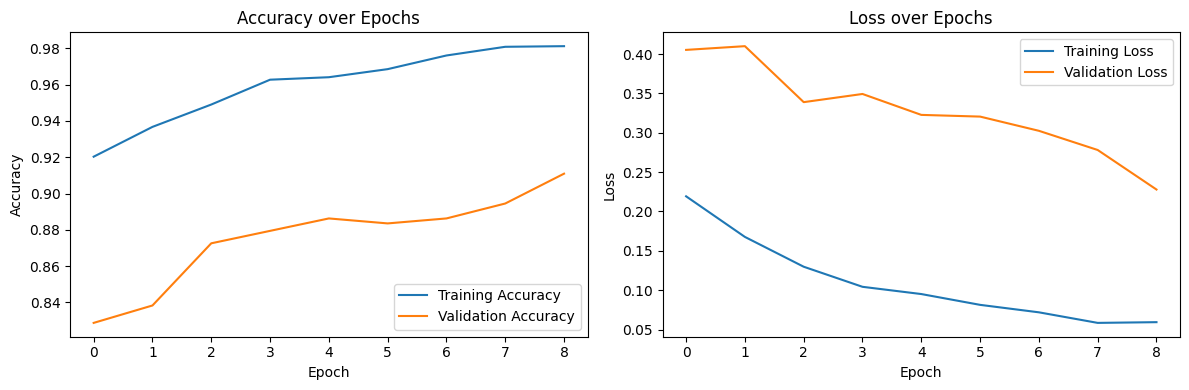

In [41]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(acc, label='Training Accuracy')
axes[0].plot(val_acc, label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()